In [ ]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 12.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1988974 sha256=3533304e25c582abedf8abb540e7080f5c6f7db0bd357d38ba8d1f8523323173
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [4]:
kmedoids = KMedoids(n_clusters=3,metric='euclidean',random_state=42)
cluster_labels = kmedoids.fit_predict(X_scaled)

In [5]:
silhouette = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score:", round(silhouette,3))

Silhouette Score: 0.459


In [6]:
df["Cluster"] = cluster_labels
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


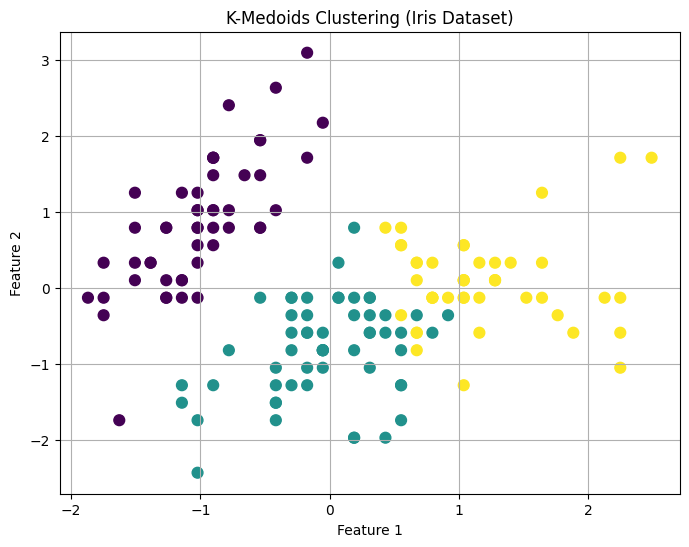

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=cluster_labels,cmap="viridis",s=60)
plt.title("K-Medoids Clustering (Iris Dataset)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()